# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
    * 음성 변환 : 강의 목소리, 톤 조절 음성 변환
    * 영상 제작 :
        * 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
        * 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
    * 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
    * 전체를 Agent 그래프로 엮기


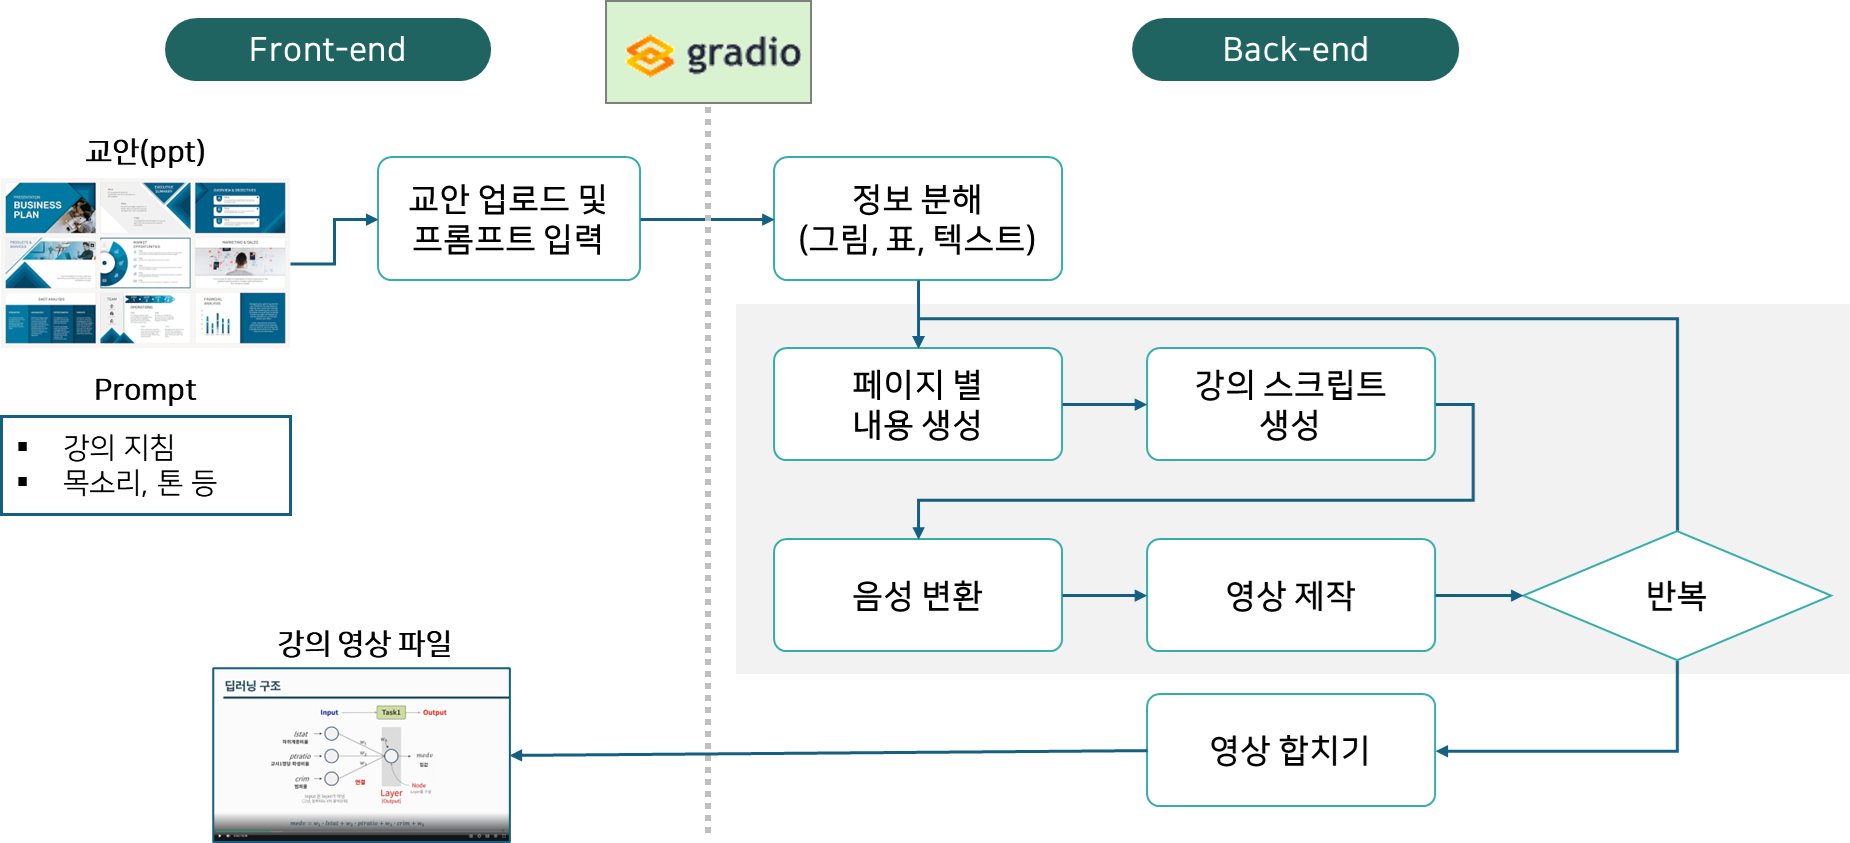

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj1_agent`를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [2]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,546 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,862 kB]
Get:13 http://archive.ubuntu.com/ubunt

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 150.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


### (3) 라이브러리

* 필요한 라이브러리 설치

In [3]:
!pip install langchain-openai langchain-community python-pptx pillow gradio langchain-tavily tavily-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


* 라이브러리 로딩

In [4]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video

from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

### (4) API Key 확인
* 구글드라이브에 생성한 폴더 `proj1_agent` 에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
    * **OPENAI_API_KEY**
    * **TAVILY_API_KEY**

In [5]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj1_agent/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [6]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['TAVILY_API_KEY'][:30])

sk-proj-s4iySMPDq8uh1ga99KDglK
tvly-dev-2l61PL-TlmqOD9un9KDVt


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [7]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [8]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

* 오디오 길이 계산

In [9]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

* 이미지를 base64로 변환

In [10]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [11]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
    * 강의 영상에서 사용할 배경 이미지 생성하기
    * ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [12]:
import os, subprocess, uuid
from pathlib import Path

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_idx", 0))  # 0-based
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    # LibreOffice 프로필(캐시) 꼬임 방지
    lo_profile = f"file:///tmp/lo_profile_{uuid.uuid4().hex}"

    # fontconfig/locale 강제
    env = os.environ.copy()
    env.update({
        "LANG": "ko_KR.UTF-8",
        "LC_ALL": "ko_KR.UTF-8",
        "FONTCONFIG_PATH": str(Path("~/.config/fontconfig").expanduser()),
        "FONTCONFIG_FILE": str(Path("~/.config/fontconfig/fonts.conf").expanduser()),
        "HOME": str(Path("~").expanduser()),
        "XDG_CACHE_HOME": str(Path("~/.cache").expanduser()),
        "SAL_USE_VCLPLUGIN": "gen",
    })

    def run_lo_convert(convert_to: str):
        # X11 요구 해결: xvfb-run로 감싼다 (Colab 필수급)
        cmd = [
            "xvfb-run", "-a",
            "soffice", "--headless", "--nologo", "--nofirststartwizard", "--norestore",
            f"-env:UserInstallation={lo_profile}",
            "--convert-to", convert_to,
            "--outdir", str(work_dir),
            str(pptx),
        ]
        return subprocess.run(cmd, capture_output=True, text=True, env=env)

    # --- A) PPTX → PNG ---
    before_png = set(work_dir.glob("*.png"))
    res_png = run_lo_convert("png:impress_png_Export")

    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
    candidate = None

    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # --- B) 폴백: PPTX → PDF → PNG ---
    before_pdf = set(work_dir.glob("*.pdf"))
    res_pdf = run_lo_convert("pdf:impress_pdf_Export")

    target_pdf = work_dir / f"{pptx.stem}.pdf"
    created_pdf = [p for p in work_dir.glob("*.pdf") if p not in before_pdf]

    if target_pdf.exists():
        pdf_path = target_pdf
    elif created_pdf:
        pdf_path = max(created_pdf, key=lambda p: p.stat().st_mtime)
    else:
        print("LibreOffice PPTX→PDF 변환 실패")
        print("stdout:", res_pdf.stdout)
        print("stderr:", res_pdf.stderr)
        raise RuntimeError("PPTX → PDF 변환 실패")

    ppm_cmd = [
        "pdftoppm",
        "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi),
        str(pdf_path),
        str(out_prefix)
    ]
    res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)

    png_path = Path(f"{out_prefix}-{page_no}.png")
    if not png_path.exists():
        print("pdftoppm 변환 실패")
        print("stdout:", res2.stdout)
        print("stderr:", res2.stderr)
        raise RuntimeError("PDF → PNG 변환 실패")

    state["slide_image"] = str(png_path)
    return state

* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [13]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
    list_path = out_path + ".txt"
    with open(list_path, "w", encoding="utf-8") as f:
        for v in video_paths:
            f.write(f"file '{os.path.abspath(v)}'\n")
    if reencode:
        cmd = [
            "ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
            "-vf","format=yuv420p",
            "-c:v","libx264","-preset","veryfast",
            "-c:a","aac","-b:a","192k",
            out_path
        ]
    else:
        cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
    subprocess.check_call(cmd)

-----

**[주의!]**🚨🚨🚨🚨🚨
* 아래 제공되는 코드 혹은 노드를 그대로 사용할 경우, 오류가 발생될 수 있습니다.
* 코드 내용을 반드시 확인하고, 여러분의 프로젝트에 맞게 수정해서 사용하세요.

-----

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력

* ppt 파일



In [14]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2.pptx


In [15]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "강의 하는 목소리 톤",
    "style": "핵심을 정확하게 전달"
}

# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)



### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [16]:
class State(TypedDict, total=False):

    pptx_path: str
    work_dir: str
    prompt: Dict[str, any]

    slides: List[Dict[str, any]]
    n_slides: int
    slide_idx: int

    page_contents: List[str]
    scripts: List[str]
    audios: List[str]
    videos: List[str]
    last_video: str

    cur_src_context: str
    cur_page_content: str
    cur_script: str
    cur_audio: str
    cur_video: str

    #페이지 요약
    all_scripts: List[str]
    summary: str

    #퀴즈 생성
    quizzes: str

In [17]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'}}

In [18]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [19]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

### (3) ppt 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
    * python-pptx로 텍스트/표/이미지 추출
    * 제목 추출
    * export_slide_as_png로 snap 생성

* 노드 함수 생성 (일부 제공)

In [20]:
def node_parse_all(state: State) -> State:
    '파서 노드 내부에서 반복문으로 모든 슬라이드 텍스트/표/이미지 + 스냅샷 생성'
    pres = Presentation(state["pptx_path"])
    work_dir = state["work_dir"]
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)
    slides_out: List[Dict[str, Any]] = []  # 함수 내에서 결과물 저장용
    # 반복문으로 각 슬라이드 마다 텍스트/표/이미지 추출
    for idx, slide in enumerate(pres.slides, start=1):
        # 텍스트/표/이미지 추출
    #처리하기
      texts, tables, images = [], [], []
      for sh in slide.shapes:
        if hasattr(sh, "has_text_frame") and sh.has_text_frame: #텍스트 처리
          txt = "\n".join(p.text for p in sh.text_frame.paragraphs)
          if txt.strip(): texts.append(clean_text(txt))
        if sh.shape_type == MSO_SHAPE_TYPE.TABLE: #테이블 처리
          t = [[clean_text(c.text) for c in r.cells] for r in sh.table.rows]
          tables.append(t)
        if sh.shape_type == MSO_SHAPE_TYPE.PICTURE: #사진 처리
          e = (sh.image.ext or "png").lower()
          path = os.path.join(media_dir, f"slide{idx:02d}_img_{len(images)+1}.{e}")
          with open(path, "wb") as f: f.write(sh.image.blob)
          images.append(path)
      # 스냅샷(export_slide_as_png 사용)
      tmp_state = {"pptx_path": state["pptx_path"], "work_dir": work_dir, "slide_idx": idx-1}
      snap_state = export_slide_as_png(tmp_state)
      snap = snap_state["slide_image"]
      # 슬라이드 title 추출
      title = ""
      if slide.shapes.title and slide.shapes.title.has_text_frame:
          title = clean_text(slide.shapes.title.text)
      # 제목 placeholder가 없으면 첫 번째 텍스트를 제목처럼 사용
      if not title and texts:
          title = texts[0].split("\n")[0]
      # 그래도 없으면 기본 제목
      if not title:
          title = f"Slide {idx}"

        # 결과물 저장
      slides_out.append({
            "index": idx,
            "title": title,
            "texts": texts,
            "tables": tables,
            "images": images,
            "snap": snap,
        })

    state["slides"] = slides_out
    state["n_slides"] = len(slides_out)
    state["slide_idx"] = 0
    state["page_contents"], state["scripts"], state["audios"], state["videos"] = [], [], [], []
    return state

* 노드 테스트

In [21]:
state = node_parse_all(state)

In [22]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

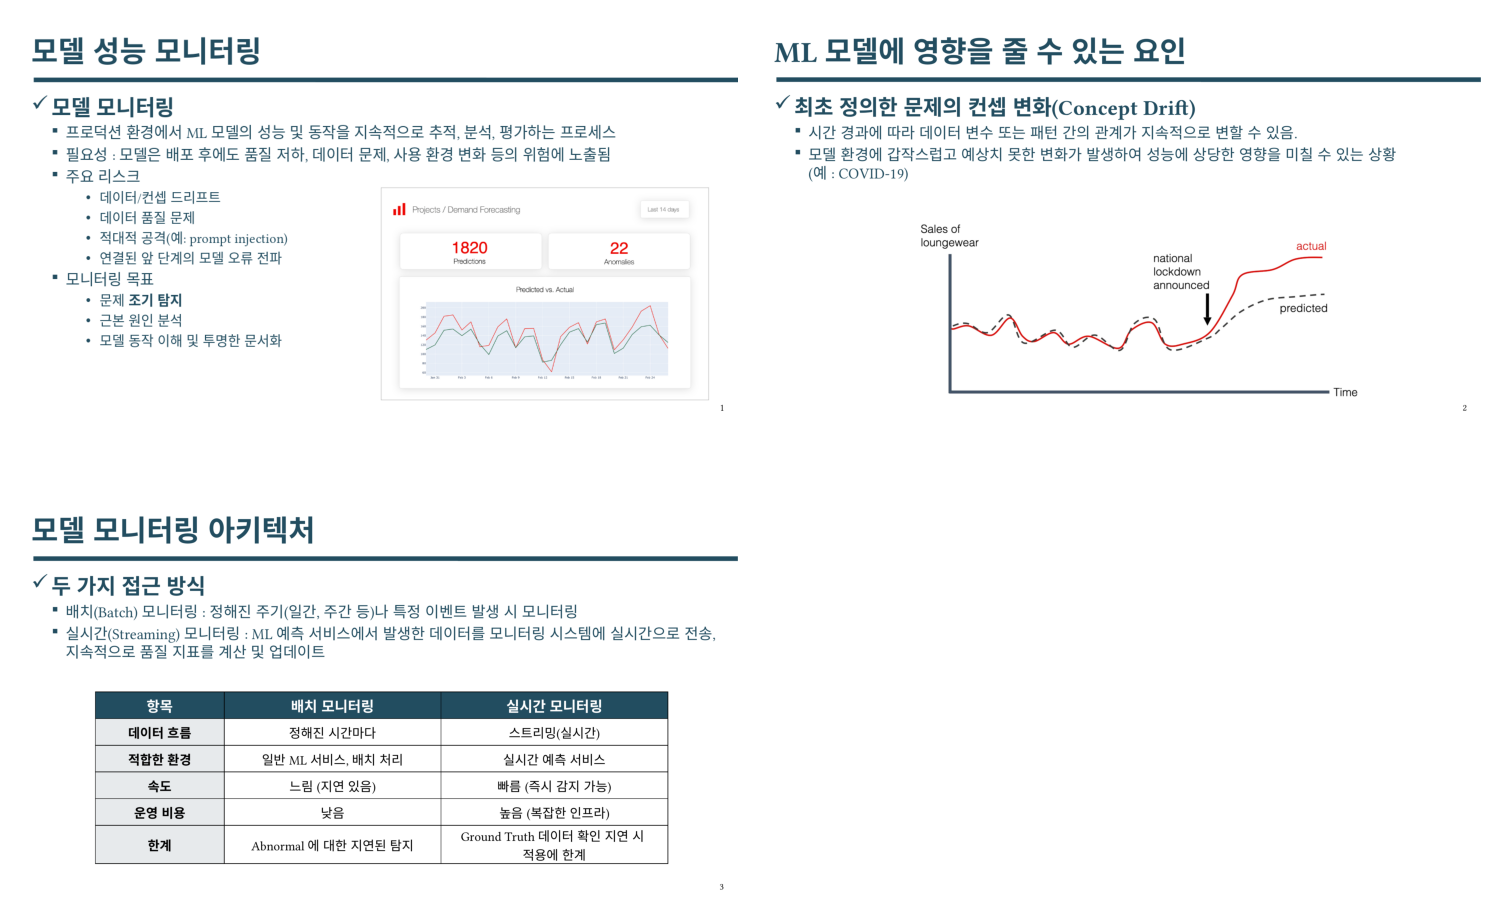

In [23]:
# 슬라이드 이미지 조회 테스트

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

n = state["n_slides"]
cols = 2
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for idx, slide in enumerate(state["slides"]):
    img_path = slide.get("snap")
    title = slide.get("title", f"Slide {idx+1}")

    plt.subplot(rows, cols, idx + 1)
    if img_path and os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.imshow(img)
    else:
        plt.text(0.5, 0.5, f"이미지 없음\n{img_path}", ha='center', va='center')

    plt.axis('off')

plt.tight_layout()
plt.show()

### (4) 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
    * 슬라이드 제목으로 SerpAPI 검색 및 요약
    * text, image, 표에 대한 설명문 생성
    * 전체 설명문 작성

#### **1) 외부 검색 노드**


In [24]:
# Tavily 도구 초기화 (max_results 설정)
tavily_tool = TavilySearch(max_results=3)

def web_search_by_title(title: str) -> str:
    """
    LangChain TavilySearch 도구를 이용하여 검색 결과를 문자열로 반환.
    """
    if not title.strip():
        return "(검색 결과 없음: 빈 제목)"

    try:
        search_result = tavily_tool.invoke({"query": title})

        # 결과가 비어있거나 에러 메시지인 경우 처리
        if not search_result:
            return "(검색 결과 없음)"

        # TavilySearch 도구는 리스트 형태의 결과를 반환하므로 이를 포맷팅
        # 결과가 이미 문자열로 넘어오는 경우를 대비해 타입을 체크
        if isinstance(search_result, list):
            lines = []
            for res in search_result:
                t = res.get("title", "No Title")
                c = res.get("content", "")
                u = res.get("url", "")
                lines.append(f"- **{t}**\n  {c}\n  URL: {u}")
            return "\n\n".join(lines)

        return str(search_result)

    except Exception as e:
        return f"(Tavily 도구 실행 중 오류 발생: {str(e)})"

def node_tool_search(state: dict) -> dict:
    """현재 슬라이드 제목으로 검색 → 요약 문자열을 임시 키에 저장"""
    i = int(state.get("slide_idx", 0))

    # 슬라이드 리스트 안전성 체크
    if not state.get("slides") or i >= len(state["slides"]):
        state["cur_search_context"] = "(검색 대상 슬라이드가 없습니다.)"
        return state

    slide = state["slides"][i]
    # 슬라이드 제목이 없으면 index 활용
    title = slide.get("title") or f"Slide {slide.get('index', i+1)}"

    print(f"--- [Slide {i+1}] '{title}' 주제로 Tavily 검색 도구 가동 중... ---")

    # 검색 수행 및 상태 업데이트
    state["cur_search_context"] = web_search_by_title(title)

    return state

In [25]:
state = node_tool_search(state)

--- [Slide 1] '모델 성능 모니터링' 주제로 Tavily 검색 도구 가동 중... ---


In [26]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

#### **2) 내용 생성 함수**

In [27]:
def node_generate_page_content(state: State) -> State:
    s = state["slides"][state["slide_idx"]]
    texts = s["texts"]
    tables = s["tables"]
    images = s["images"]
    title = s.get("title") or f"Slide {s.get('index', state['slide_idx'] + 1)}"

    # 표 요약(첫 표 6행까지만 문자열화)
    table_snip = ""
    if tables:
        try:
            table_snip = "\n".join([" | ".join(map(str, r)) for r in tables[0][:6]])
        except Exception:
            table_snip = str(tables[0][:6])

    # Tool Node가 넣어준 검색 요약 문자열 사용
    src_bullets = state.get("cur_search_context", "(검색 결과 없음)")

    sys_msg = """
# 역할 : 너는 발표 슬라이드의 핵심을 요약하고, 검색 소스를 근거로 내용을 보강하는 조교다.

# 지침
- 반드시 제공된 제목, 텍스트, 표, 이미지, 검색 소스에만 근거해 작성한다.
- 과장하거나 추측하지 않는다.
- 결과는 4~6문장 분량의 하나의 자연스러운 단락으로 작성한다.
- 검색 소스에 없는 사실은 추가하지 않는다.
- 이미지가 텍스트나 표의 어떤 내용을 보완하는지도 1~2문장 포함한다.
- 스타일은 사용자 지시를 따른다.
"""

    user_text = f"""[제목]
{title}

[텍스트]
{json.dumps(texts, ensure_ascii=False, indent=2) if texts else '(없음)'}

[표 요약]
{table_snip if table_snip else '(없음)'}

[검색 소스(요약)]
{src_bullets}

[작성 스타일]
{state["prompt"].get("style", "간결")}
"""

    # 멀티모달 HumanMessage 구성
    human_msg = [{"type": "text", "text": user_text}]

    MAX_IMGS = 2
    for p in images[:MAX_IMGS]:
        try:
            human_msg.append({
                "type": "image_url",
                "image_url": {"url": img_to_data_url(p)}
            })
        except Exception:
            pass

    response = llm.invoke([SystemMessage(content=sys_msg),
                           HumanMessage(content=human_msg)])

    state["cur_page_content"] = response.content.strip()
    return state

* 노드 테스트

In [28]:
state = node_generate_page_content(state)

In [29]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

### (5) 강의 스크립트

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
    * 슬라이드 설명문
    * tone, 말투 지시 프롬프트
    * 스크립트 저장 디렉토리
    * 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [30]:
writer_llm = ChatOpenAI(model=LLM_MODEL, temperature=0.6)
reviewer_llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

In [31]:
def node_generate_script(state: State) -> State:
    """
    슬라이드 설명문을 바탕으로 강의용 발표 스크립트를 생성하고 저장합니다.
    """
    # 1. 입력 데이터 준비
    cur_idx = state["slide_idx"]
    page_content = state.get("cur_page_content", "")
    work_dir = state.get("work_dir", "./")

    # 말투 및 스타일 지시문 (State 내 prompt 딕셔너리 활용)
    prompt_config = state.get("prompt", {})
    voice_tone = prompt_config.get("tone", "친절하고 전문적인 구어체")

    # 이전 페이지 스크립트 맥락 파악 (흐름 연결용)
    prev_script = ""
    if cur_idx > 0 and "scripts" in state and len(state["scripts"]) > 0:
        prev_script = state["scripts"][-1]

    # 2. LLM 프롬프트 구성
    system_msg = f"귀하는 전문 강사이며, 제공된 내용을 바탕으로 {voice_tone}로 발표 대본을 작성하는 전문가입니다."

    user_msg = f"""
    아래의 슬라이드 내용을 바탕으로 약 60초에서 90초 분량의 강의 스크립트를 작성해 주세요.

    [현재 슬라이드 내용 요약]:
    {page_content}

    [이전 페이지 스크립트 맥락]:
    {prev_script if prev_script else "첫 번째 슬라이드입니다."}

    [작성 규칙]:
    1. 말투: {voice_tone}를 사용하여 자연스러운 구어체로 작성하세요.
    2. 구조: 도입부(연결) -> 본문(설명) -> 마무리(요약 및 전환)의 흐름을 갖추세요.
    3. 분량: 읽었을 때 60~90초가 소요되도록 충분한 디테일을 포함하세요.
    4. 흐름: 이전 페이지가 있다면 자연스럽게 이어지도록 연결 문장을 포함하세요.
    5. 금지: "슬라이드를 보시면", "다음 표는"과 같은 표현보다는 내용을 직접 설명하는 방식으로 작성하세요.
    """

    # 3. 스크립트 생성 호출
    response = llm.invoke([
        SystemMessage(content=system_msg),
        HumanMessage(content=user_msg)
    ])

    script_text = response.content

    # 4. 결과 저장 (파일 및 State)
    # 스크립트 저장 디렉토리 생성
    script_dir = os.path.join(work_dir, "scripts")
    os.makedirs(script_dir, exist_ok=True)

    # 파일 저장 (예: slide01_script.txt)
    file_path = os.path.join(script_dir, f"slide{cur_idx+1:02d}_script.txt")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(script_text)

    # State 업데이트
    state["cur_script"] = script_text
    if "scripts" not in state or state["scripts"] is None:
        state["scripts"] = []
    state["scripts"].append(script_text)

    print(f"--- [Slide {cur_idx+1}] 강의 스크립트 생성 및 저장 완료 ({file_path}) ---")

    return state

* 테스트

In [32]:
state = node_generate_script(state)

--- [Slide 1] 강의 스크립트 생성 및 저장 완료 (./step2_output/scripts/slide01_script.txt) ---


In [33]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
    * 발표 스크립트
    * 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [34]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "shimmer",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

In [35]:
def node_tts(state: State) -> State:
    client = OpenAI()
    mp3_path = os.path.join(state["work_dir"], f"narration_{state['slide_idx']+1:02d}.mp3")
    resp = client.audio.speech.create(
        model=TTS_MODEL,
        voice=state["prompt"].get("voice","shimmer"),
        input=state["cur_script"])
    with open(mp3_path, "wb") as f:
        f.write(resp.content)
    state["cur_audio"] = mp3_path
    return state

* 노드 테스트

In [36]:
state = node_tts(state)

In [37]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [38]:
def node_make_video(state: State) -> State:
    # 1. 슬라이드 스테이트를 불러온후 오디오에 cur_audio로 저장
    s = state["slides"][state["slide_idx"]]
    img = s["snap"]
    audio = state["cur_audio"]
    # 3. 렌더링후 비디오 저장
    out_mp4 = os.path.join(
        state["work_dir"],
        f"slide{state['slide_idx'] + 1:02d}_lecture.mp4"
    )
    render_mp4(img, audio, out_mp4)
    state["cur_video"] = out_mp4
    return state

In [39]:
state = node_make_video(state)

In [40]:
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy', 'tone': '강의 하는 목소리 톤', 'style': '핵심을 정확하게 전달'},
 'slides': [{'index': 1,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./step2_output/media/slide01_img_1.png'],
   'snap': '/content/step2_output/sample2.png'},
  {'index': 2,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)',
    'ML 모델에 영향을 줄 수 있는 요인',
    '2'],
   'tables': [],
   'images': ['./step2_output/media/slide02_img_1.png'],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '모델 모니터링 

In [41]:
video_path = state["cur_video"]
with open(video_path, "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

Output hidden; open in https://colab.research.google.com to view.

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

* State의 키(리스트)에 누적

In [42]:
def node_accumulate_and_step(state: State) -> State:
    # 누적
    state["page_contents"].append(state["cur_page_content"])
    state["scripts"].append(state["cur_script"])
    state["audios"].append(state["cur_audio"])
    state["videos"].append(state["cur_video"])
    # 다음 슬라이드로
    state["slide_idx"] += 1
    return state

* 분기 함수

In [43]:
def router_continue_or_done(state: State) -> str:
    return "CONTINUE" if state["slide_idx"] < state["n_slides"] else "DONE"

* 영상 합치기
    * concat_videos_ffmpeg 사용

In [44]:
def node_concat(state: State) -> State:
    out_path = os.path.join(state["work_dir"], "lecture_full.mp4")
    concat_videos_ffmpeg(state["videos"], out_path)
    state["last_video"] = out_path


    return state

(4) 전체 내용 요약 및 퀴즈 생성 노드


In [45]:
#전체 내용 요약 노드
def node_generate_final_summary(state: State) -> State:
  # 1. 앞선 노드(node_generate_page_content)의 반복 실행으로 모인
  # 전체 페이지의 텍스트(스크립트)를 하나로 병합합니다.
  # (State 스키마에 전체 스크립트를 리스트 형태로 모아둔 키가 있다고 가정합니다. 예: 'all_scripts')
  all_scripts = "\n\n".join(state.get("scripts", []))
  # 2. 시스템 프롬프트: 원리와 논리 흐름 중심의 요약 지시
  sys_msg = """
  너는 IT 전문 강의의 핵심을 짚어주는 튜터 에이전트다.
  제공된 전체 강의 스크립트를 바탕으로 전체 요약본을 작성한다.
  # 지침
  - 지엽적인 사실의 단순 나열이나 진득한 암기를 요구하는 요약은 배제한다.
  - 학습자가 강의의 '핵심 원리'와 '전체적인 논리 흐름'을 단번에 이해할 수 있도록 인과관계 중심으로 구조화한다.
  - 결과는 4~5개의 마크다운 글머리 기호(-)를 사용하여 가독성 있게 정리한다.
  """
  user_text = f"[전체 강의 스크립트]\n{all_scripts}"
  # 3. LLM 호출 (여기서는 텍스트만 필요하므로 이미지는 제외)
  response = llm.invoke([
      SystemMessage(content=sys_msg),
      HumanMessage(content=user_text)
  ])
  # 4. State에 요약 결과 저장 (앞서 수정한 Gradio에서 이 'summary' 키를 꺼내 쓰게 됩니다)
  state["summary"] = response.content.strip()
  return state

In [46]:
#퀴즈 생성 노드
def node_generate_quizzes(state: State) -> State:
    print("--- 💡 퀴즈 생성 노드 진입 ---")
    # 앞선 노드에서 생성한 요약본 가져오기
    summary = state.get("summary", "")
    # 시스템 프롬프트: 원리 이해 중심의 퀴즈 출제 지시
    sys_msg = """
    너는 학습자의 이해도를 점검하는 튜터 에이전트다.
    제공된 '핵심 요약'을 바탕으로 O/X형 퀴즈 3개를 출제한다.
    # 지침
    - 작동 원리와 논리적 흐름을 제대로 이해했는지 묻는 문제로 구성한다.
    - 웹 화면에 출력할 것이므로 가독성 좋은 마크다운 형식으로 작성한다.
    - 각 문제의 정답과 해설은 학습자가 먼저 고민해볼 수 있도록 아래 HTML 태그를 사용하여 숨김 처리한다.
    <details>
    <summary>💡 정답 및 해설 보기</summary>
    - 정답: O
    - 해설: (왜 이 논리가 성립하는지 원리 위주로 간략히 설명)
    </details>
    """
    user_text = f"[강의 핵심 요약]\n{summary}"
    response = llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_text)
    ])
    print("--- 💡 LLM 퀴즈 응답 ---")
    print(response.content) # LLM이 답변을 제대로 생성했는지 터미널에서 확인
    # State에 퀴즈 결과 저장
    state["quizzes"] = response.content.strip()
    return state

### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

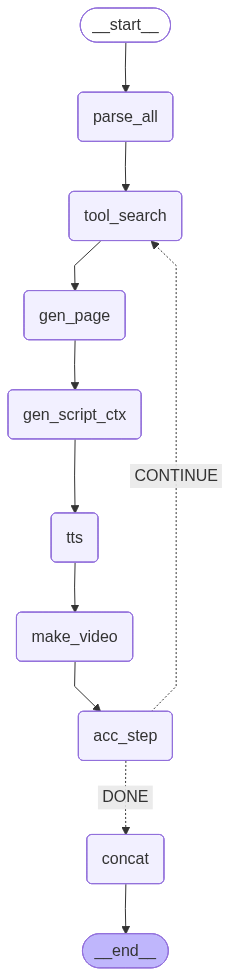

In [47]:
from langgraph.graph import StateGraph, END
builder = StateGraph(State)
builder.add_node("parse_all",      node_parse_all)
builder.add_node("tool_search",    node_tool_search)           # 🔹 추가
builder.add_node("gen_page",       node_generate_page_content)
builder.add_node("gen_script_ctx", node_generate_script)
builder.add_node("tts",            node_tts)
builder.add_node("make_video",     node_make_video)
builder.add_node("acc_step",       node_accumulate_and_step)
builder.add_node("concat",         node_concat)
builder.add_node("gen_summary",    node_generate_final_summary)
builder.add_node("gen_quizzes",    node_generate_quizzes)


builder.set_entry_point("parse_all")
builder.add_edge("parse_all", "tool_search")                   # 🔹 먼저 검색
builder.add_edge("tool_search", "gen_page")                    # 🔹 검색 요약 → 내용 생성
builder.add_edge("gen_page", "gen_script_ctx")
builder.add_edge("gen_script_ctx", "tts")
builder.add_edge("tts", "make_video")
builder.add_edge("make_video", "acc_step")
builder.add_conditional_edges("acc_step", router_continue_or_done,
                                {"CONTINUE": "tool_search", "DONE": "concat"})  # 🔹 루프 내에서도 검색 먼저
builder.add_edge("concat", 'gen_summary')
builder.add_edge("gen_summary", 'gen_quizzes')
builder.add_edge("gen_quizzes", END)
app = builder.compile()

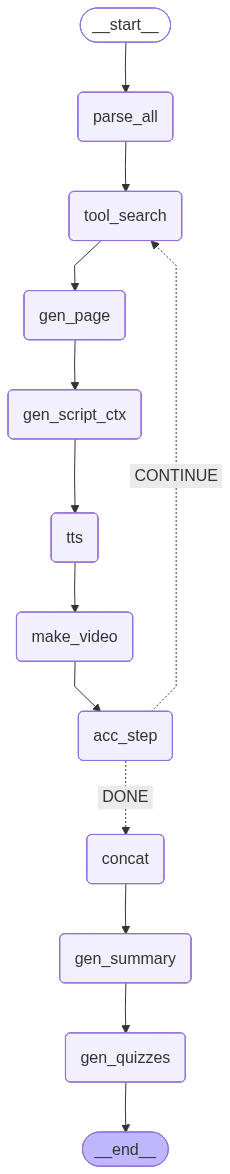

In [48]:
app

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [49]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2 (1).pptx


In [50]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "shimmer",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [51]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'shimmer',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심'}}

In [52]:
final_state = app.invoke(state)

--- [Slide 1] '모델 성능 모니터링' 주제로 Tavily 검색 도구 가동 중... ---
--- [Slide 1] 강의 스크립트 생성 및 저장 완료 (./step2_output/scripts/slide01_script.txt) ---
--- [Slide 2] 'ML 모델에 영향을 줄 수 있는 요인' 주제로 Tavily 검색 도구 가동 중... ---
--- [Slide 2] 강의 스크립트 생성 및 저장 완료 (./step2_output/scripts/slide02_script.txt) ---
--- [Slide 3] '모델 모니터링 아키텍처' 주제로 Tavily 검색 도구 가동 중... ---
--- [Slide 3] 강의 스크립트 생성 및 저장 완료 (./step2_output/scripts/slide03_script.txt) ---
--- 💡 퀴즈 생성 노드 진입 ---
--- 💡 LLM 퀴즈 응답 ---
## O/X형 퀴즈

1. 머신러닝 모델은 프로덕션 환경에 배포된 후에도 품질 저하와 데이터 문제에 직면할 수 있기 때문에 성능 모니터링이 필수적이다.  
   <details>
   <summary>💡 정답 및 해설 보기</summary>
   - 정답: O
   - 해설: 머신러닝 모델은 다양한 외부 요인으로 인해 성능이 저하될 수 있으므로, 이를 지속적으로 모니터링하여 문제를 조기에 발견하는 것이 중요하다.
   </details>

2. 데이터 드리프트와 컨셉 드리프트는 모델의 성능에 영향을 미치지 않기 때문에 모니터링할 필요가 없다.  
   <details>
   <summary>💡 정답 및 해설 보기</summary>
   - 정답: X
   - 해설: 데이터 드리프트와 컨셉 드리프트는 모델의 성능에 직접적인 영향을 미치므로, 이를 모니터링하는 것이 필수적이다.
   </details>

3. 배치 모니터링과 실시간 모니터링은 속도와 운영 비용 측면에서 차이를 보인다.  
   <details>
   <summary>💡 정답 및 해

In [ ]:
final_state

In [54]:
video_path = final_state.get("last_video")
print("최종 영상:", video_path)

with open(video_path, "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

Output hidden; open in https://colab.research.google.com to view.

## **5. Web APP 개발(Gradio)**
* 화면 개발
    * 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
    * 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.
    * 그래프 컴파일 이름 : `app`
    * state에서 출력 비디오 이름 : `final_video`

In [59]:
import os, time, shutil
import gradio as gr
VOICES = ["alloy", "aria", "verse", "shimmer", "coral", "sage", "nova", "amber"]
def run_pipeline_ui(pptx_file, tone, voice):
    # 작업 디렉터리 & 업로드 저장
    work_dir = os.path.join("./webio", f"run-{int(time.time())}")
    os.makedirs(work_dir, exist_ok=True)
    pptx_path = os.path.join(work_dir, "input.pptx")
    shutil.copy(pptx_file.name, pptx_path)
    # 초기 state (State 스키마에 맞춤)
    state = {
        "pptx_path": pptx_path,
        "work_dir": work_dir,
        "prompt": {
            "voice": voice or "alloy",
            "tone":  tone or "친절하고 명료한 강의 톤",
            "style": "예시와 핵심 요점 중심",
        },
    }
    # 그래프 실행
    final_state = app.invoke(state)
    video_path = final_state.get("last_video")
    summary_text = final_state.get("summary", "요약 내용이 없습니다.")
    quizzes_text = final_state.get("quizzes", "퀴즈가 없습니다.")
    return video_path, video_path, summary_text, quizzes_text
# -------------------- Gradio UI --------------------
with gr.Blocks(title="AI 강사 Agent") as demo:
    gr.Markdown("### PPT --> 강의영상 자동 제작")
    with gr.Row():
        inp_ppt = gr.File(label="PPTX 업로드", file_types=[".pptx"])
        with gr.Column():
            inp_tone  = gr.Textbox(value="친절하고 명료한 강의 톤", label="강의 작성 톤 (프롬프트)")
            inp_voice = gr.Dropdown(VOICES, value="alloy", label="TTS Voice")
    run_btn = gr.Button("실행", variant="primary")
    out_video    = gr.Video(label="최종 동영상 미리보기", interactive=False)
    out_download = gr.DownloadButton(label="동영상 다운로드")
    out_summary = gr.Textbox(
        label = "핵심 원리 요약",
        lines = 8,
        interactive = False
    )
    gr.Markdown("### 📝 이해 점검 퀴즈") # 고정된 제목
    out_quizzes = gr.Markdown()
    run_btn.click(run_pipeline_ui, [inp_ppt, inp_tone, inp_voice], [out_video, out_download, out_summary, out_quizzes])
demo.queue().launch()
print("FINAL STATE:", final_state)
print("퀴즈:", final_state.get("quizzes"))

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
--- 💡 LLM 퀴즈 응답 ---
# O/X 퀴즈

## 문제 1
머신러닝 모델이 프로덕션 환경에 배포된 후, 데이터 품질 저하와 환경 변화는 모델 성능에 긍정적인 영향을 미칠 수 있다.  
- O / X

<details>
<summary>💡 정답 및 해설 보기</summary>
- 정답: X
- 해설: 데이터 품질 저하와 환경 변화는 모델 성능에 부정적인 영향을 미칠 수 있으며, 이는 모델의 예측 정확도를 저하시킬 수 있다.
</details>

---

## 문제 2
모니터링은 머신러닝 모델의 성능 저하를 조기에 탐지하고 문제의 근본 원인을 분석하는 데 필수적이다.  
- O / X

<details>
<summary>💡 정답 및 해설 보기</summary>
- 정답: O
- 해설: 성능 모니터링을 통해 리스크를 조기에 발견하고, 문제를 해결하기 위한 분석을 수행할 수 있어 모델의 신뢰성을 높이는 데 기여한다.
</details>

---

## 문제 3
실시간 모니터링은 배치 모니터링보다 빠르게 데이터를 처리할 수 있지만, 운영 비용이 높고 복잡한 인프라가 필요하다.  
- O / X

<details>
<summary>💡 정답 및 해설 보기</summary>
- 정답: O
- 해설: 실시간 모니터링은 즉각적인 데이터 전송과 품질 지표 업데이트가 가능하지만, 그만큼 운영 비용과 인프라의 복잡성이 증가한다.
</details>
* Runn

FINAL STATE: {'pptx_path': 'sample2 (1).pptx', 'work_dir': './step2_output', 'prompt': {'voice': 'shimmer', 'tone': '친절하고 명료한 강의 톤', 'style': '예시와 핵심 요점 중심'}, 'slides': [{'index': 1, 'title': '모델 성능 모니터링', 'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화', '모델 성능 모니터링', '1'], 'tables': [], 'images': ['./step2_output/media/slide01_img_1.png'], 'snap': '/content/step2_output/sample2 (1).png'}, {'index': 2, 'title': 'ML 모델에 영향을 줄 수 있는 요인', 'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관계가 지속적으로 변할 수 있음. 모델 환경에 갑작스럽고 예상치 못한 변화가 발생하여 성능에 상당한 영향을 미칠 수 있는 상황 (예 : COVID-19)', 'ML 모델에 영향을 줄 수 있는 요인', '2'], 'tables': [], 'images': ['./step2_output/media/slide02_img_1.png'], 'snap': '/content/step2_output/slide_img-2.png'}, {'index': 3, 'title': '모델 모니터링 아키텍처', 'texts': ['두 가지 접근 방식 배